# Part 3 — Model Design and Improvement: MCTNet+
 


## 1. Imports & Configuration

In [8]:
import os
import re
import json
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')

DATA_DIR = r'C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Crop-Classification\Data'
COV_DIR  = os.path.join(DATA_DIR, 'covariates')
AR_PATH  = os.path.join(DATA_DIR, 'sentinel', 'arkansas.csv')
CA_PATH  = os.path.join(DATA_DIR, 'sentinel', 'california.csv')
SAVE_DIR = DATA_DIR

COV_FILES = {
    'AR': [
        os.path.join(COV_DIR, 'MCTNet_Arkansas_Zone1_covariates.csv'),
        os.path.join(COV_DIR, 'MCTNet_Arkansas_Zone2_covariates.csv'),
    ],
    'CA': [
        os.path.join(COV_DIR, 'MCTNet_California_Zone1_covariates.csv'),
        os.path.join(COV_DIR, 'MCTNet_California_Zone2_covariates.csv'),
    ],
}

N_TIMESTEPS = 36
N_BANDS     = 10
BAND_ORDER  = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
META_COLS   = ['label', 'crop_name', 'lat', 'lon',
               'latitude', 'longitude', 'system:index', '.geo', 'crop_id']
DOY         = [(i + 1) * 10 for i in range(N_TIMESTEPS)]

RENAME_MAP = {
    'precip_annual_mm'  : 'precipitation',  'precipitation'  : 'precipitation',
    'temp_mean_degC'    : 'temperature',     'temperature'    : 'temperature',
    'solar_mean_Wm2'    : 'solar_radiation', 'solar_radiation': 'solar_radiation',
    'soil_pH_0cm'       : 'soil_pH',         'soil_pH'        : 'soil_pH',
    'soil_OC_gkg'       : 'organic_carbon',  'organic_carbon' : 'organic_carbon',
    'soil_texture_class': 'soil_texture',    'soil_texture'   : 'soil_texture',
    'elevation_m'       : 'elevation',       'elevation'      : 'elevation',
    'landforms_class'   : 'landforms',       'landforms'      : 'landforms',
}
ALL_COVS = ['precipitation', 'temperature', 'solar_radiation',
            'soil_pH', 'organic_carbon', 'soil_texture',
            'elevation', 'landforms']

N_HEADS      = 5
KERNEL_SIZE  = 3
DROPOUT      = 0.1
LR           = 0.001
N_EPOCHS     = 200
BATCH_SIZE   = 32
WEIGHT_DECAY = 1e-4
PATIENCE     = 25
COV_EMBED    = 32
CROSS_HEADS  = 4

PAPER_AR = {'OA': 0.968, 'Kappa': 0.951, 'F1': 0.933}
PAPER_CA = {'OA': 0.852, 'Kappa': 0.806, 'F1': 0.829}
PART1_AR = {'OA': 0.952, 'Kappa': 0.927, 'F1': 0.863}
PART1_CA = {'OA': 0.901, 'Kappa': 0.853, 'F1': 0.646}
PART2_AR = {'OA': 0.949, 'Kappa': 0.922, 'F1': 0.860}
PART2_CA = {'OA': 0.923, 'Kappa': 0.883, 'F1': 0.695}

Device  : cpu
PyTorch : 2.11.0+cpu


## 2. Data Loading & Preprocessing



In [9]:
df_ar = pd.read_csv(AR_PATH)
df_ca = pd.read_csv(CA_PATH)

cov_ar = load_covariates(COV_FILES['AR'])
cov_ca = load_covariates(COV_FILES['CA'])

C_ar, cov_names_ar = align_covariates(df_ar, cov_ar)
C_ca, cov_names_ca = align_covariates(df_ca, cov_ca)

print(f'Arkansas   : {len(df_ar):,} pixels  | covariates: {cov_names_ar}')
print(f'California : {len(df_ca):,} pixels  | covariates: {cov_names_ca}')

Arkansas   : 10,000 pixels  | covariates: ['precipitation', 'temperature', 'solar_radiation', 'soil_pH', 'organic_carbon', 'soil_texture', 'elevation', 'landforms']
California : 10,000 pixels  | covariates: ['precipitation', 'temperature', 'solar_radiation', 'soil_pH', 'organic_carbon', 'soil_texture', 'elevation', 'landforms']


In [10]:
def extract_latlon(df):
    if 'lat' in df.columns and 'lon' in df.columns:
        return df['lat'].values, df['lon'].values
    elif 'latitude' in df.columns and 'longitude' in df.columns:
        return df['latitude'].values, df['longitude'].values
    elif '.geo' in df.columns:
        coords = df['.geo'].apply(lambda x: json.loads(x)['coordinates'])
        return coords.apply(lambda c: c[1]).values, coords.apply(lambda c: c[0]).values
    raise ValueError('No lat/lon columns found.')


def load_covariates(file_list):
    df_cov = pd.concat([pd.read_csv(f) for f in file_list], ignore_index=True)
    df_cov = df_cov.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df_cov.columns})
    lats, lons = extract_latlon(df_cov)
    df_cov['_lat'] = lats
    df_cov['_lon'] = lons
    return df_cov


def align_covariates(df_sentinel, df_cov):
    sent_lats, sent_lons = extract_latlon(df_sentinel)
    cov_coords  = np.deg2rad(np.column_stack([df_cov['_lat'].values, df_cov['_lon'].values]))
    tree        = BallTree(cov_coords, metric='haversine')
    sent_coords = np.deg2rad(np.column_stack([sent_lats, sent_lons]))
    _, indices  = tree.query(sent_coords, k=1)
    available   = [c for c in ALL_COVS if c in df_cov.columns]
    return df_cov.iloc[indices.flatten()][available].values.astype(np.float32), available


def get_feature_cols(df):
    return [c for c in df.columns if c not in META_COLS]


def sort_feature_columns(feat_cols):
    def key(col):
        m = re.search(r'_t(\d+)$', col)
        t = int(m.group(1)) if m else 0
        b = re.sub(r'_t\d+$', '', col)
        return (t, BAND_ORDER.index(b) if b in BAND_ORDER else 99)
    return sorted(feat_cols, key=key)


def preprocess(df, C_full, seed=42,
               n_train_default=240, n_val_default=60,
               n_train_small=120,   n_val_small=30,
               small_threshold=300, min_test=30):
    rng = np.random.RandomState(seed)

    feat_cols = sort_feature_columns(get_feature_cols(df))
    X_raw = df[feat_cols].values.reshape(-1, N_TIMESTEPS, N_BANDS).astype(np.float32)
    mask  = (~np.isnan(X_raw).any(axis=2)).astype(np.float32)
    X_raw = np.nan_to_num(X_raw, nan=0.0)

    le = LabelEncoder()
    y  = le.fit_transform(df['crop_name'].values)

    train_idx, val_idx, test_idx = [], [], []

    print(f'\n  {"Class":<20} {"Total":>6} {"Train":>6} {"Val":>5} {"Test":>6}  Protocol')
    print('  ' + '-' * 60)

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        n = len(idx)

        if n >= small_threshold and (n - n_train_default - n_val_default) >= min_test:
            nt, nv = n_train_default, n_val_default
            protocol = 'paper (240/60)'
        else:
            nt = min(n_train_small, int(n * 0.6))
            nv = min(n_val_small,   int(n * 0.2))
            protocol = f'small  ({nt}/{nv})'

        # Garantir au moins min_test échantillons test
        if nt + nv > n - min_test:
            nv = max(1, int(n * 0.15))
            nt = max(1, n - nv - min_test)

        train_idx.extend(idx[:nt])
        val_idx.extend(idx[nt:nt + nv])
        test_idx.extend(idx[nt + nv:])

        cls_name = le.classes_[cls]
        print(f'  {cls_name:<20} {n:>6} {nt:>6} {nv:>5} {n - nt - nv:>6}  {protocol}')

    tr = np.array(train_idx)
    va = np.array(val_idx)
    te = np.array(test_idx)

    X_tr, mask_tr, y_tr = X_raw[tr], mask[tr], y[tr]
    X_va, mask_va, y_va = X_raw[va], mask[va], y[va]
    X_te, mask_te, y_te = X_raw[te], mask[te], y[te]

    norm_mean = X_tr.mean(axis=(0, 1), keepdims=True)
    norm_std  = X_tr.std(axis=(0, 1),  keepdims=True) + 1e-8
    X_tr = (X_tr - norm_mean) / norm_std
    X_va = (X_va - norm_mean) / norm_std
    X_te = (X_te - norm_mean) / norm_std

    C_tr = C_full[tr].astype(np.float32)
    C_va = C_full[va].astype(np.float32)
    C_te = C_full[te].astype(np.float32)

    cov_mean = C_tr.mean(axis=0, keepdims=True)
    cov_std  = C_tr.std(axis=0,  keepdims=True) + 1e-8
    C_tr = (C_tr - cov_mean) / cov_std
    C_va = (C_va - cov_mean) / cov_std
    C_te = (C_te - cov_mean) / cov_std

    print(f'\n  Train : {len(y_tr):>5} samples ({len(np.unique(y_tr))} classes)')
    print(f'  Val   : {len(y_va):>5} samples')
    print(f'  Test  : {len(y_te):>5} samples')

    return {
        'X_train': X_tr, 'mask_train': mask_tr, 'C_train': C_tr, 'y_train': y_tr,
        'X_val':   X_va, 'mask_val':   mask_va, 'C_val':   C_va, 'y_val':   y_va,
        'X_test':  X_te, 'mask_test':  mask_te, 'C_test':  C_te, 'y_test':  y_te,
        'norm_mean': norm_mean, 'norm_std': norm_std,
        'cov_mean': cov_mean,   'cov_std':  cov_std,  'le': le,
    }


print('--- Arkansas ---')
data_ar = preprocess(df_ar, C_ar)

print('\n--- California ---')
data_ca = preprocess(df_ca, C_ca)

--- Arkansas ---

  Class                 Total  Train   Val   Test  Protocol
  ------------------------------------------------------------
  Corn                   1320    240    60   1020  paper (240/60)
  Cotton                 1052    240    60    752  paper (240/60)
  Others                  430    240    60    130  paper (240/60)
  Rice                   2430    240    60   2130  paper (240/60)
  Soybeans               4768    240    60   4468  paper (240/60)

  Train :  1200 samples (5 classes)
  Val   :   300 samples
  Test  :  8500 samples

--- California ---

  Class                 Total  Train   Val   Test  Protocol
  ------------------------------------------------------------
  Alfalfa                 301    120    30    151  small  (120/30)
  Almonds                 585    240    60    285  paper (240/60)
  Grapes                 3471    240    60   3171  paper (240/60)
  Others                 3842    240    60   3542  paper (240/60)
  Pistachios              454    24

## 3. Dataset & DataLoaders

In [11]:
class CropDataset(Dataset):
    def __init__(self, X, mask, C, y):
        C_rep   = np.repeat(C[:, np.newaxis, :], X.shape[1], axis=1)
        X_fused = np.concatenate([X, C_rep], axis=2)
        self.X    = torch.FloatTensor(X_fused)
        self.mask = torch.FloatTensor(mask)
        self.y    = torch.LongTensor(y)
 
    def __len__(self): return len(self.y)
 
    def __getitem__(self, i):
        return self.X[i], self.mask[i], self.y[i]
 
 
def make_loaders(data, batch_size=32):
    tr = CropDataset(data['X_train'], data['mask_train'], data['C_train'], data['y_train'])
    va = CropDataset(data['X_val'],   data['mask_val'],   data['C_val'],   data['y_val'])
    te = CropDataset(data['X_test'],  data['mask_test'],  data['C_test'],  data['y_test'])
    input_dim = tr.X.shape[2]
    return (
        DataLoader(tr, batch_size=batch_size, shuffle=True,  drop_last=True),
        DataLoader(va, batch_size=batch_size, shuffle=False),
        DataLoader(te, batch_size=batch_size, shuffle=False),
        input_dim,
    )
 
 
loaders_ar = make_loaders(data_ar, BATCH_SIZE)
loaders_ca = make_loaders(data_ca, BATCH_SIZE)
n_cov = data_ar['C_train'].shape[1]
print(f'DataLoaders ready. input_dim = {loaders_ar[3]}  (10 Sentinel + {n_cov} covariates)')

DataLoaders ready. input_dim = 18  (10 Sentinel + 8 covariates)


## 4. Model Architecture — MCTNet+



In [12]:
class ALPE(nn.Module):
    def __init__(self, n_times=36, n_bands=10):
        super().__init__()
        pe = torch.zeros(n_times, n_bands)
        for t in range(n_times):
            for i in range(0, n_bands, 2):
                pe[t, i]     = math.sin(t / (10000 ** (2 * i / n_bands)))
                if i + 1 < n_bands:
                    pe[t, i+1] = math.cos(t / (10000 ** (2 * i / n_bands)))
        self.register_buffer('pe', pe.unsqueeze(0))
        self.conv     = nn.Conv1d(n_bands, n_bands, kernel_size=3, padding=1)
        self.eca_pool = nn.AdaptiveAvgPool1d(1)
        self.eca_conv = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid  = nn.Sigmoid()
 
    def forward(self, x, mask):
        pe_masked = self.pe * mask.unsqueeze(-1)
        pe_t = self.conv(pe_masked.permute(0, 2, 1))
        attn = self.eca_pool(pe_t)
        attn = self.sigmoid(self.eca_conv(attn.permute(0, 2, 1))).permute(0, 2, 1)
        return x + (pe_t * attn).permute(0, 2, 1)
 
 
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(d_model * 2, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)
 
    def forward(self, x):
        a, _ = self.attn(x, x, x)
        x    = self.norm1(x + self.drop(a))
        return self.norm2(x + self.drop(self.ffn(x)))
 
 
class CNNSubModule(nn.Module):
    def __init__(self, d_model, kernel_size=3, dropout=0.1):
        super().__init__()
        p = kernel_size // 2
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size, padding=p)
        self.bn1   = nn.BatchNorm1d(d_model)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size, padding=p)
        self.bn2   = nn.BatchNorm1d(d_model)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(dropout)
 
    def forward(self, x):
        residual = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.drop(x)
        return self.relu(self.bn2(self.conv2(x)) + residual)
 
 
class CBAM(nn.Module):
    def __init__(self, d_model, reduction=4):
        super().__init__()
        reduced = max(d_model // reduction, 4)
 
        self.ch_avg = nn.AdaptiveAvgPool1d(1)
        self.ch_max = nn.AdaptiveMaxPool1d(1)
        self.ch_mlp = nn.Sequential(
            nn.Linear(d_model, reduced), nn.ReLU(),
            nn.Linear(reduced, d_model), nn.Sigmoid(),
        )
 
        self.t_conv = nn.Sequential(
            nn.Conv1d(2, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid(),
        )
 
    def forward(self, x):
 
        x_t = x.permute(0, 2, 1)
        avg_c = self.ch_avg(x_t).squeeze(-1)
        max_c = self.ch_max(x_t).squeeze(-1)
        ch_w  = self.ch_mlp(avg_c) + self.ch_mlp(max_c)
        x = x * ch_w.unsqueeze(1)
 
        avg_t = x.mean(dim=2, keepdim=True)
        max_t = x.max(dim=2, keepdim=True).values
        t_in  = torch.cat([avg_t, max_t], dim=2).permute(0, 2, 1)
        t_w   = self.t_conv(t_in).permute(0, 2, 1)
        x = x * t_w
 
        return x
 
 
class CTFusionCBAM(nn.Module):
    def __init__(self, in_ch, out_ch, n_heads, kernel_size=3,
                 dropout=0.1, use_alpe=False, n_times=36):
        super().__init__()
        self.use_alpe = use_alpe
        half = out_ch // 2
 
        if use_alpe:
            self.alpe = ALPE(n_times=n_times, n_bands=in_ch)
 
        self.proj        = nn.Linear(in_ch, out_ch)
        self.cnn         = CNNSubModule(half, kernel_size, dropout)
        self.transformer = TransformerSubModule(half, n_heads, dropout)
        self.pool        = nn.MaxPool1d(kernel_size=2, stride=2)
        self.cbam        = CBAM(out_ch)
 
    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            x = self.alpe(x, mask)
 
        x    = self.proj(x)
        half = x.shape[-1] // 2
        x_c  = self.cnn(x[..., :half].permute(0, 2, 1)).permute(0, 2, 1)
        x_t  = self.transformer(x[..., half:])
        x    = torch.cat([x_c, x_t], dim=-1)
        x    = self.pool(x.permute(0, 2, 1)).permute(0, 2, 1)
        x    = self.cbam(x)
        return x
 
 
class MCTNetPlus(nn.Module):
    def __init__(self, n_bands, n_classes, n_heads=5, kernel_size=3,
                 dropout=0.1, n_times=36):
        super().__init__()
        self.stage1 = CTFusionCBAM(n_bands, 20, n_heads=n_heads,
                                   kernel_size=kernel_size, dropout=dropout,
                                   use_alpe=True, n_times=n_times)
        self.stage2 = CTFusionCBAM(20, 40, n_heads=n_heads,
                                   kernel_size=kernel_size, dropout=dropout)
        self.stage3 = CTFusionCBAM(40, 80, n_heads=n_heads,
                                   kernel_size=kernel_size, dropout=dropout)
        self.classifier = nn.Linear(80, n_classes)
        self.drop = nn.Dropout(dropout)
 
    def forward(self, x, mask):
        x = self.stage1(x, mask)
        x = self.stage2(x)
        x = self.stage3(x)
        x = x.max(dim=1).values
        x = self.drop(x)
        return self.classifier(x)
 
 
n_classes_ar = len(data_ar['le'].classes_)
n_classes_ca = len(data_ca['le'].classes_)
input_dim    = loaders_ar[3]
 
model_test = MCTNetPlus(input_dim, n_classes_ar, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)
x_d    = torch.randn(4, N_TIMESTEPS, input_dim).to(device)
mask_d = torch.ones(4, N_TIMESTEPS).to(device)
out    = model_test(x_d, mask_d)
 
print(f'MCTNet+ output shape  : {out.shape}  (expected [4, {n_classes_ar}])')
n_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Trainable parameters  : {n_params:,}')
del model_test

MCTNet+ output shape  : torch.Size([4, 5])  (expected [4, 5])
Trainable parameters  : 40,905


## 5. Training

In [13]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    total_loss = 0.0
    criterion  = nn.CrossEntropyLoss()
 
    for X_b, mask_b, y_b in loader:
        X_b, mask_b = X_b.to(device), mask_b.to(device)
        logits = model(X_b, mask_b)
        total_loss += criterion(logits, y_b.to(device)).item()
        preds.extend(logits.argmax(1).cpu().numpy())
        labels.extend(y_b.numpy())
 
    oa    = accuracy_score(labels, preds)
    kappa = cohen_kappa_score(labels, preds)
    f1    = f1_score(labels, preds, average='macro', zero_division=0)
    return oa, kappa, f1, total_loss / len(loader), preds, labels
 
 
def train(model, data, loaders, region):
    train_loader, val_loader, _ = loaders[:3]
 
    y_train = train_loader.dataset.y.numpy()
    class_weights = compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(class_weights).to(device)
    )
    optimizer = optim.Adam(model.parameters(), lr=LR)
 
    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0
    history       = {'train_loss': [], 'val_loss': [], 'val_oa': [], 'val_f1': []}
 
    print(f'Training MCTNet+ — {region}')
    print(f'{"Epoch":<8} {"Train Loss":<14} {"Val Loss":<12} {"Val OA":<10} {"Val F1"}')
    print('-' * 55)
 
    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        train_loss = 0.0
 
        for X_b, mask_b, y_b in train_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b, mask_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
 
        train_loss /= len(train_loader)
        val_oa, _, val_f1, val_loss, _, _ = evaluate(model, val_loader)
 
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_oa'].append(val_oa)
        history['val_f1'].append(val_f1)
 
        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:<8} {train_loss:<14.4f} {val_loss:<12.4f} {val_oa:<10.4f} {val_f1:.4f}')
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'\nEarly stopping at epoch {epoch}')
                break
 
    model.load_state_dict(best_state)
    print(f'Done. Best val loss: {best_val_loss:.4f}')
    return history
 
 
model_ar = MCTNetPlus(input_dim, n_classes_ar, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)
history_ar = train(model_ar, data_ar, loaders_ar, 'Arkansas')
 
print()
 
model_ca = MCTNetPlus(input_dim, n_classes_ca, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)
history_ca = train(model_ca, data_ca, loaders_ca, 'California')

Training MCTNet+ — Arkansas
Epoch    Train Loss     Val Loss     Val OA     Val F1
-------------------------------------------------------
1        1.4876         1.4751       0.3800     0.3398
10       0.3143         0.4222       0.8867     0.8847
20       0.1452         0.3384       0.9100     0.9090
30       0.0695         0.3838       0.9267     0.9264
40       0.0296         0.4570       0.9200     0.9185

Early stopping at epoch 44
Done. Best val loss: 0.2824

Training MCTNet+ — California
Epoch    Train Loss     Val Loss     Val OA     Val F1
-------------------------------------------------------
1        1.3582         1.1511       0.5455     0.5162
10       0.2820         0.4363       0.8424     0.8451
20       0.1488         0.4749       0.8788     0.8879
30       0.0751         0.5986       0.8848     0.8888

Early stopping at epoch 36
Done. Best val loss: 0.3841


## 6. Evaluation & Comparison

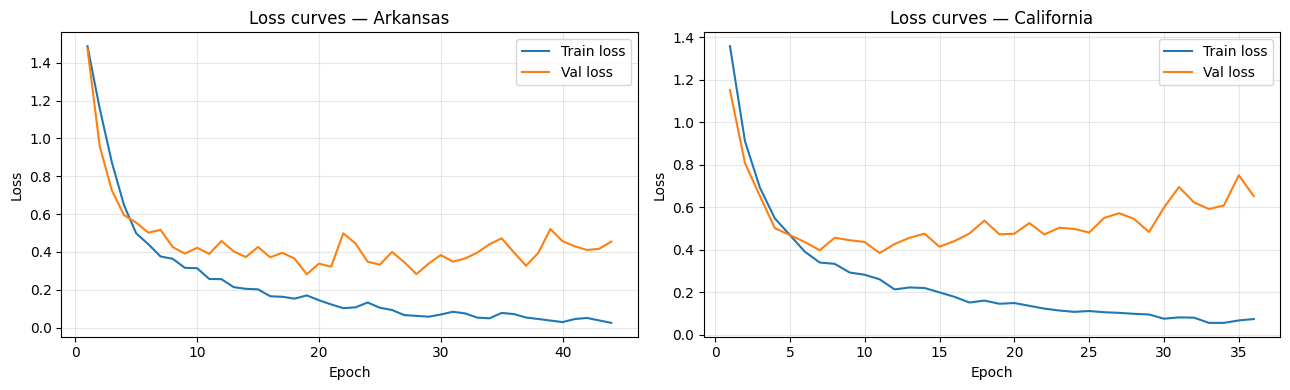


                                OA    Kappa       F1

Arkansas
Paper (target)               0.968    0.951    0.933
Part 1 — MCTNet              0.952      0.927      0.863
Part 2 — MCTNet+Cov D4       0.949      0.922      0.860
Part 3 — MCTNet+             0.903      0.856      0.805
  vs Part 1 → OA -0.049   F1 -0.058

California
Paper (target)               0.852    0.806    0.829
Part 1 — MCTNet              0.901      0.853      0.646
Part 2 — MCTNet+Cov D4       0.923      0.883      0.695
Part 3 — MCTNet+             0.909      0.865      0.789
  vs Part 1 → OA +0.008   F1 +0.143


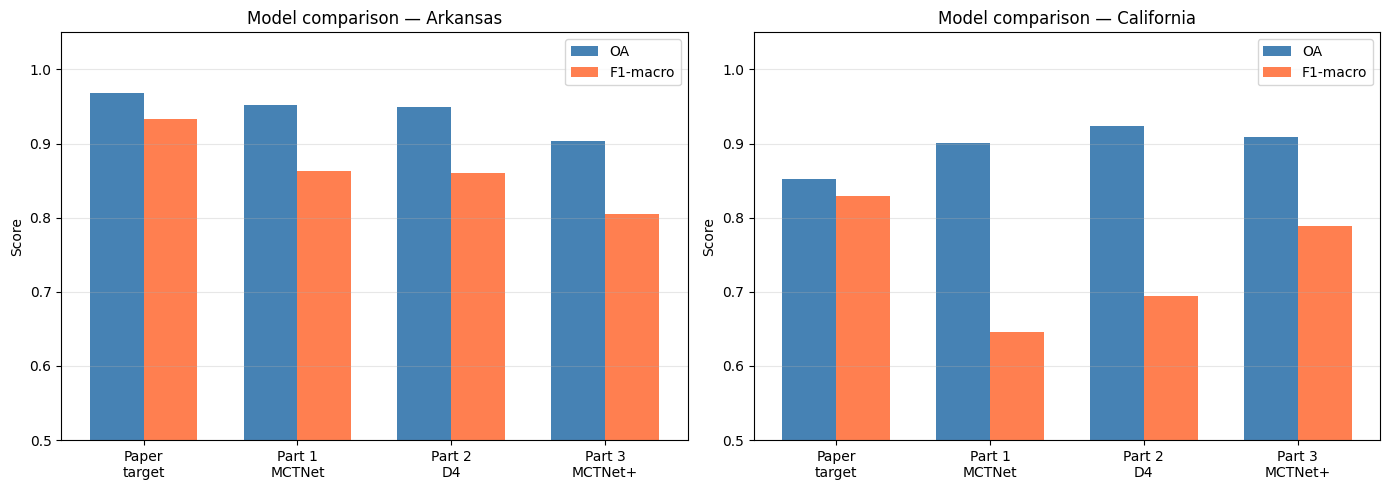

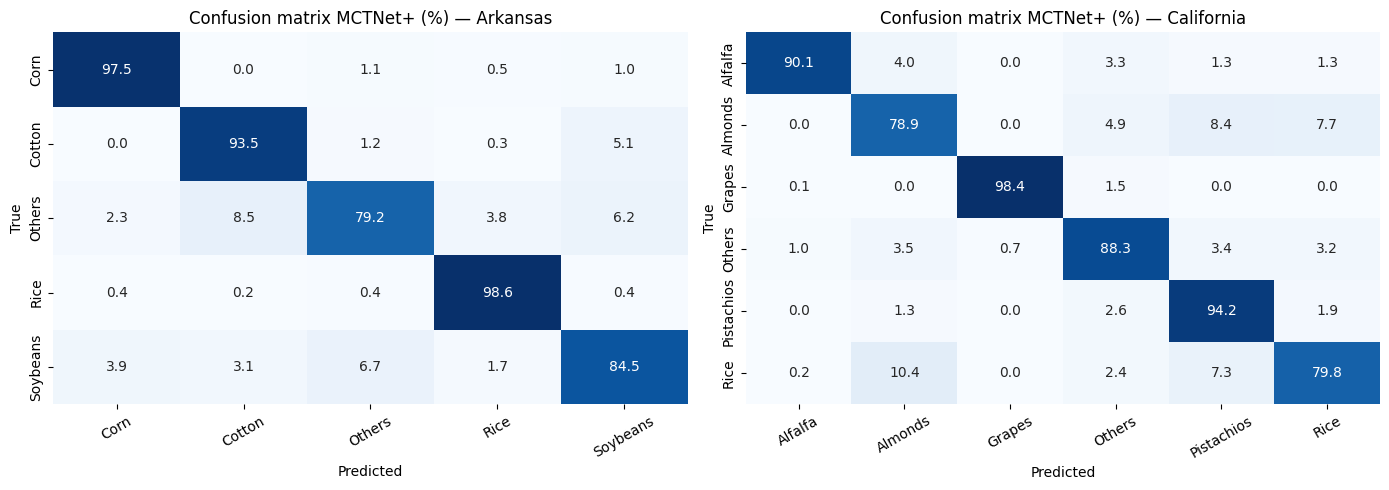


--- Classification report — Arkansas ---
              precision    recall  f1-score   support

        Corn      0.842     0.975     0.904      1020
      Cotton      0.819     0.935     0.873       752
      Others      0.238     0.792     0.367       130
        Rice      0.960     0.986     0.973      2130
    Soybeans      0.983     0.845     0.909      4468

    accuracy                          0.903      8500
   macro avg      0.769     0.907     0.805      8500
weighted avg      0.934     0.903     0.913      8500


--- Classification report — California ---
              precision    recall  f1-score   support

     Alfalfa      0.782     0.901     0.837       151
     Almonds      0.484     0.789     0.600       285
      Grapes      0.992     0.984     0.988      3171
      Others      0.970     0.883     0.925      3542
  Pistachios      0.395     0.942     0.557       154
        Rice      0.856     0.798     0.826      1047

    accuracy                          0.909  

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, history, region in zip(axes, [history_ar, history_ca], ['Arkansas', 'California']):
    ep = range(1, len(history['train_loss']) + 1)
    ax.plot(ep, history['train_loss'], label='Train loss')
    ax.plot(ep, history['val_loss'],   label='Val loss')
    ax.set_title(f'Loss curves — {region}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


results = {}
for model, loaders, data, region in [
    (model_ar, loaders_ar, data_ar, 'Arkansas'),
    (model_ca, loaders_ca, data_ca, 'California'),
]:
    train_loader, val_loader, test_loader, _ = loaders
    oa, kappa, f1, _, preds, labels = evaluate(model, test_loader)
    results[region] = {
        'OA': oa, 'Kappa': kappa, 'F1': f1,
        'preds': preds, 'labels': labels, 'le': data['le']
    }


print(f'\n{"": <25} {"OA":>8} {"Kappa":>8} {"F1":>8}')
print('=' * 52)

for region, paper, p1, p2 in [
    ('Arkansas',   PAPER_AR, PART1_AR, PART2_AR),
    ('California', PAPER_CA, PART1_CA, PART2_CA),
]:
    r  = results[region]
    p3 = r
    print(f'\n{region}')
    print(f'{"Paper (target)":<25} {paper["OA"]:>8.3f} {paper["Kappa"]:>8.3f} {paper["F1"]:>8.3f}')
    print(f'{"Part 1 — MCTNet":<25} {p1["OA"]:>8.3f}   {p1["Kappa"]:>8.3f}   {p1["F1"]:>8.3f}')
    print(f'{"Part 2 — MCTNet+Cov D4":<25} {p2["OA"]:>8.3f}   {p2["Kappa"]:>8.3f}   {p2["F1"]:>8.3f}')
    print(f'{"Part 3 — MCTNet+":<25} {p3["OA"]:>8.3f}   {p3["Kappa"]:>8.3f}   {p3["F1"]:>8.3f}')
    delta_oa = p3['OA'] - p1['OA']
    delta_f1 = p3['F1'] - p1['F1']
    print(f'  vs Part 1 → OA {delta_oa:+.3f}   F1 {delta_f1:+.3f}')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, region, paper, p1, p2 in [
    (axes[0], 'Arkansas',   PAPER_AR, PART1_AR, PART2_AR),
    (axes[1], 'California', PAPER_CA, PART1_CA, PART2_CA),
]:
    p3     = results[region]
    models = ['Paper\ntarget', 'Part 1\nMCTNet', 'Part 2\nD4', 'Part 3\nMCTNet+']
    oa_v   = [paper['OA'], p1['OA'], p2['OA'], p3['OA']]
    f1_v   = [paper['F1'], p1['F1'], p2['F1'], p3['F1']]

    x = np.arange(len(models))
    w = 0.35
    ax.bar(x - w/2, oa_v, w, label='OA',       color='steelblue')
    ax.bar(x + w/2, f1_v, w, label='F1-macro',  color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_title(f'Model comparison — {region}')
    ax.set_ylabel('Score')
    ax.set_ylim(0.5, 1.05)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, region in zip(axes, ['Arkansas', 'California']):
    r    = results[region]
    cm   = confusion_matrix(r['labels'], r['preds'])
    cm_p = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cm_p, annot=True, fmt='.1f', cmap='Blues',
        xticklabels=r['le'].classes_, yticklabels=r['le'].classes_,
        ax=ax, cbar=False
    )
    ax.set_title(f'Confusion matrix MCTNet+ (%) — {region}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


for region in ['Arkansas', 'California']:
    r = results[region]
    print(f'\n--- Classification report — {region} ---')
    print(classification_report(
        r['labels'], r['preds'],
        target_names=list(r['le'].classes_), digits=3
    ))

## 7. Save Model

In [15]:
for model, data, history, region_key in [
    (model_ar, data_ar, history_ar, 'AR'),
    (model_ca, data_ca, history_ca, 'CA'),
]:
    path = os.path.join(SAVE_DIR, f'mctnet_plus_{region_key}.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'le_classes':       data['le'].classes_,
        'norm_mean':        data['norm_mean'],
        'norm_std':         data['norm_std'],
        'cov_mean':         data['cov_mean'],
        'cov_std':          data['cov_std'],
        'n_bands':          input_dim,
        'history':          history,
    }, path)
    print(f'Saved: {path}')

Saved: C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Last-version\Data\mctnet_plus_AR.pth
Saved: C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Last-version\Data\mctnet_plus_CA.pth
